## Embedding Method - Feature Extraction.

Embedding training is a feature extraction method , we can say it is a deep learning method where we train the vector of each word per batch and get the optimum value through backpropagation. 

How are embeddings updated?
    
Standard flow :
- Input Sentence -> Embedding -> CNN -> Dense -> Softmax.
  The above is a standard flow of embedding + cnn deep learning model. 
    
- Creating an embedding matrix
  $$E \in \mathbb{R}^{V \times d}$$

- V = vocabulary size
- d = embedding dimension

Compute Loss: 
- if we use crossentropy = $$L = \text{crossentropy}(y, \hat{y})$$

Compute Gradients wrt loss and vector update: 
- $$\frac{\partial E[i]}{\partial L}$$
- gradient: $$g_i = \frac{\partial L}{\partial E[i]}$$
- If optimizer is SGD: $$E[i] := E[i] - \eta \cdot g_i$$
- If optimizer is ADAM : $$E[i] := E[i] - \eta \cdot \frac{m_i}{\sqrt{v_i} + \epsilon}$$

#### Model Training: 

Using this vectorizing method we will train Deep Learning Models:
- CNN - We will use a 1D Convolutional Model with kernel of dimension 3x1
- MLP - Using a standard MLP Architecture with 256 , 128 neurons in input and hidden layer.

## Embedding Method – Feature Extraction

Before training deep learning models, raw text must be converted into numeric form. We use the Tokenizer + Embedding method to achieve this.


$$
\text{Input} \;\rightarrow\; \text{Tokenizer} 
           \;\rightarrow\; \text{Embedding}
           \;\rightarrow\; \text{CNN / MLP}
           \;\rightarrow\; \text{Softmax}
$$


### Tokenizer

The Keras Tokenizer preprocesses and converts text into sequences of integers by:

- lowercasing text

- removing punctuation

- splitting into words (tokens)

- building a vocabulary of the top 𝑉 most frequent words

- mapping each word to an integer ID

- padding sequences to a fixed length

Each sentence becomes:
$$ sentence→[w1,w2,…,wT] $$
Embedding Layer

### An embedding matrix is initialized:

Where:

- $V$ = vocabulary size

- $𝑑$ = embedding dimension

Each integer token 
𝑖 retrieves vector $E[i]$.
These vectors are learned during training using backpropagation.

### Updating Embeddings

Given loss $𝐿$ (crossentropy):

$$
L = -\sum_{c} y_c \log(\hat{y}_c)
$$

SGD update:
$$
E[i] := E[i] - \eta \cdot g_i
$$


Adam update:
$$
E[i] := E[i] - \eta \cdot \frac{m_i}{\sqrt{v_i} + \epsilon}
$$

Only vectors corresponding to words in the batch are updated.

### Model Training

Using this vectorized representation, we train:

CNN Model

Embedding → Conv1D(kernel=3) → GlobalMaxPool → Dense → Softmax

MLP Model

Embedding → Dense(256) → Dense(128) → Dense(output)

Both models learn classification patterns using the embedding vectors as features.

In [49]:
import pandas as pd
import numpy as np
import random 
import re
from datasets import load_dataset
import time
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [50]:
#loading dataset

dataset = load_dataset('ag_news')
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

X_train = train_df['text']
y_train = train_df['label']
X_test = test_df['text']
y_test = test_df['label']


In [51]:
X_train

0         Wall St. Bears Claw Back Into the Black (Reute...
1         Carlyle Looks Toward Commercial Aerospace (Reu...
2         Oil and Economy Cloud Stocks' Outlook (Reuters...
3         Iraq Halts Oil Exports from Main Southern Pipe...
4         Oil prices soar to all-time record, posing new...
                                ...                        
119995    Pakistan's Musharraf Says Won't Quit as Army C...
119996    Renteria signing a top-shelf deal Red Sox gene...
119997    Saban not going to Dolphins yet The Miami Dolp...
119998    Today's NFL games PITTSBURGH at NY GIANTS Time...
119999    Nets get Carter from Raptors INDIANAPOLIS -- A...
Name: text, Length: 120000, dtype: object

In [52]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 65000            # enough for AG News
max_len = 200                 # sentence length
oov_token = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(X_train)

# convert text → integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# pad to fixed length
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


In [53]:
X_train_seq

[[443,
  442,
  1682,
  14529,
  109,
  65,
  2,
  851,
  22,
  22,
  754,
  8197,
  443,
  6641,
  10232,
  2928,
  5,
  5811,
  25990,
  41,
  4050,
  798,
  333],
 [14992,
  1100,
  878,
  1304,
  4246,
  22,
  22,
  921,
  812,
  353,
  14992,
  100,
  103,
  23,
  4,
  4522,
  9,
  509,
  510,
  13268,
  7,
  14993,
  1521,
  2177,
  6,
  2,
  531,
  248,
  23,
  3937,
  2294,
  16,
  6561,
  8,
  213,
  369,
  5,
  2,
  129],
 [54,
  7,
  377,
  4577,
  25991,
  767,
  22,
  22,
  2427,
  463,
  91,
  1905,
  1284,
  67,
  2,
  377,
  7,
  2,
  767,
  9,
  285,
  41,
  192,
  3,
  5812,
  35,
  2,
  297,
  129,
  112,
  83,
  234,
  2,
  6205,
  5,
  2,
  1215,
  14994],
 [74,
  7405,
  54,
  1841,
  24,
  894,
  555,
  2900,
  22,
  22,
  861,
  36,
  4947,
  54,
  3601,
  7895,
  24,
  2,
  894,
  2900,
  6,
  555,
  74,
  29,
  1451,
  728,
  4,
  781,
  2582,
  92,
  515,
  3058,
  25,
  54,
  303,
  20,
  8,
  121],
 [54,
  91,
  4443,
  3,
  111,
  82,
  141,
  7473,
  18,


In [54]:
X_train_pad

array([[  443,   442,  1682, ...,     0,     0,     0],
       [14992,  1100,   878, ...,     0,     0,     0],
       [   54,     7,   377, ...,     0,     0,     0],
       ...,
       [ 7888,    60,   673, ...,     0,     0,     0],
       [ 4291,   782,   233, ...,     0,     0,     0],
       [ 2331,   226,  2515, ...,     0,     0,     0]])

In [55]:
from tensorflow.keras.utils import to_categorical

num_classes = 4  # AG News has 4 categories
y_train_oh = to_categorical(y_train, num_classes)
y_test_oh = to_categorical(y_test, num_classes)


In [56]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

embedding_dim = 128
filters = 128
kernel_size = 3

cnn_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len, name="embedding"),

    Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
    GlobalMaxPooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 128)          8320000   
                                                                 
 conv1d_1 (Conv1D)           (None, 198, 128)          49280     
                                                                 
 global_max_pooling1d_1 (Glo  (None, 128)              0         
 balMaxPooling1D)                                                
                                                                 
 dense_5 (Dense)             (None, 64)                8256      
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_6 (Dense)             (None, 4)                 260       
                                                      

In [57]:
%%time
cpu_start_time = time.process_time()
start_time = time.time()

history = cnn_model.fit(
    X_train_pad, y_train_oh,
    validation_split=0.1,
    epochs=5,
    batch_size=1000
)

cpu_end_time = time.process_time()
end_time = time.time()
cpu_time_train = cpu_end_time - cpu_start_time
cell_time_train =  end_time - start_time
print(cpu_time_train)
print(cell_time_train)

Epoch 1/5
108/108 [==============================] - 59s 538ms/step - loss: 0.7989 - accuracy: 0.7230 - val_loss: 0.2941 - val_accuracy: 0.9018
Epoch 2/5
108/108 [==============================] - 44s 403ms/step - loss: 0.2693 - accuracy: 0.9197 - val_loss: 0.2556 - val_accuracy: 0.9123
Epoch 3/5
108/108 [==============================] - 37s 343ms/step - loss: 0.1803 - accuracy: 0.9461 - val_loss: 0.2585 - val_accuracy: 0.9101
Epoch 4/5
108/108 [==============================] - 53s 491ms/step - loss: 0.1239 - accuracy: 0.9638 - val_loss: 0.2915 - val_accuracy: 0.9052
Epoch 5/5
108/108 [==============================] - 56s 514ms/step - loss: 0.0840 - accuracy: 0.9757 - val_loss: 0.3189 - val_accuracy: 0.9030
2140.0625
248.04921054840088
CPU times: total: 35min 40s
Wall time: 4min 8s


In [58]:
%%time
cpu_start_time = time.process_time()
start_time = time.time()

y_pred_probs = cnn_model.predict(X_test_pad)

cpu_end_time = time.process_time()
end_time = time.time()
cpu_time_inf = cpu_end_time - cpu_start_time
cell_time_inf =  end_time - start_time
print(cpu_time_inf)
print(cell_time_inf)

238/238 [==============================] - 3s 11ms/step
10.796875
3.0844056606292725
CPU times: total: 10.8 s
Wall time: 3.08 s


In [59]:
y_pred_test = np.argmax(y_pred_probs, axis=1)

y_train_probs = cnn_model.predict(X_train_pad)
y_train_pred = np.argmax(y_train_probs,axis=1)

3750/3750 [==============================] - 45s 12ms/step


In [60]:
y_train_oh

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.]], dtype=float32)

In [61]:
y_train_pred

array([2, 2, 2, ..., 1, 1, 1], dtype=int64)

In [62]:
print("Training Accuracy")
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_report = classification_report(y_train, y_train_pred)
print('\n Training Accuracy',train_accuracy)
print('\n Training F1 Score',train_f1)
print('\n Training Classification Report',train_report)

Training Accuracy

 Training Accuracy 0.9814666666666667

 Training F1 Score 0.9814622068513287

 Training Classification Report               precision    recall  f1-score   support

           0       0.98      0.98      0.98     30000
           1       0.99      1.00      0.99     30000
           2       0.98      0.97      0.97     30000
           3       0.97      0.98      0.98     30000

    accuracy                           0.98    120000
   macro avg       0.98      0.98      0.98    120000
weighted avg       0.98      0.98      0.98    120000



In [63]:
print("Test Accuracy")
test_accuracy = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_report = classification_report(y_test,y_pred_test)
print('\n Test Accuracy',test_accuracy)
print('\n Test F1 Score',test_f1)
print('\n Test Classification Report',test_report)

Test Accuracy

 Test Accuracy 0.91

 Test F1 Score 0.9098488080506274

 Test Classification Report               precision    recall  f1-score   support

           0       0.91      0.92      0.91      1900
           1       0.96      0.97      0.96      1900
           2       0.88      0.87      0.88      1900
           3       0.89      0.88      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



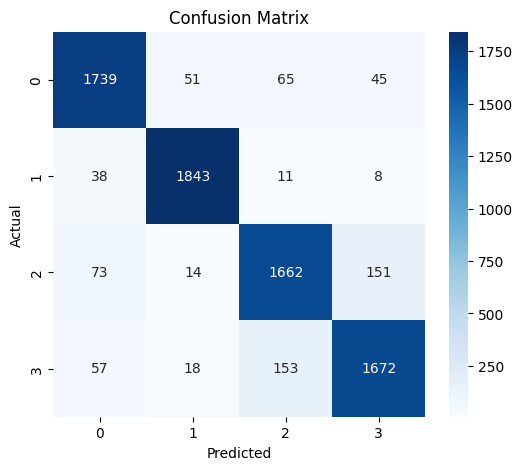

In [66]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('images/cm_cnn_embedding.png')
plt.show()

Per each sample ,the FLOPs carried can be calculated by the formula below. This is entirely dependent on the architecture.
$$FLOPs=2×(sequence length)×(kernel size)×(embedding dim)×(filters)$$

In [67]:
flops = 2 * 200 * 3 * 128 * 128
print("The FLOPs carried out per sample is: ", flops)

The FLOPs carried out per sample is:  19660800


In [68]:
results = {}
results[('Matrix Embedding','CNN Model')] = {
                                    'Train':
                                            {'accuracy': train_accuracy,
                                            'f1_score': train_f1,
                                            'report': train_report,
                                            'training_time': cpu_time_train},
                                    'Test':
                                            {'accuracy': test_accuracy,
                                            'f1_score': test_f1,
                                            'report': test_report,
                                            'inference_time':cpu_time_inf,
                                            "flops/sample": flops}}

### MLP Model:

In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout
from tensorflow.keras import regularizers

embedding_dim = 128

mlp_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

mlp_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

mlp_model.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 200, 128)          8320000   
                                                                 
 flatten_1 (Flatten)         (None, 25600)             0         
                                                                 
 dense_7 (Dense)             (None, 256)               6553856   
                                                                 
 dropout_4 (Dropout)         (None, 256)               0         
                                                                 
 dense_8 (Dense)             (None, 128)               32896     
                                                                 
 dropout_5 (Dropout)         (None, 128)               0         
                                                                 
 dense_9 (Dense)             (None, 4)                

In [70]:
%%time
cpu_start_time = time.process_time()
start_time = time.time() 

history_mlp = mlp_model.fit(
    X_train_pad,
    y_train_oh,
    validation_split=0.1,
    epochs=5,
    batch_size=128
)

cpu_end_time = time.process_time()
end_time = time.time()

cpu_train_time = cpu_end_time - cpu_start_time
cell_time = end_time - start_time
print(cpu_train_time)


Epoch 1/5
844/844 [==============================] - 104s 120ms/step - loss: 0.5309 - accuracy: 0.8570 - val_loss: 0.3426 - val_accuracy: 0.9151
Epoch 2/5
844/844 [==============================] - 97s 115ms/step - loss: 0.2721 - accuracy: 0.9472 - val_loss: 0.3880 - val_accuracy: 0.9040
Epoch 3/5
844/844 [==============================] - 102s 121ms/step - loss: 0.1918 - accuracy: 0.9740 - val_loss: 0.4405 - val_accuracy: 0.8932
Epoch 4/5
844/844 [==============================] - 133s 158ms/step - loss: 0.1424 - accuracy: 0.9866 - val_loss: 0.4430 - val_accuracy: 0.8980
Epoch 5/5
844/844 [==============================] - 104s 123ms/step - loss: 0.1226 - accuracy: 0.9900 - val_loss: 0.4659 - val_accuracy: 0.8932
2883.328125
CPU times: total: 48min 3s
Wall time: 9min


In [71]:
%%time
cpu_start_time = time.process_time()
start_time = time.time()

y_pred_probs = mlp_model.predict(X_test_pad)

cpu_end_time = time.process_time()
end_time = time.time()
cpu_time_inf = cpu_end_time - cpu_start_time
cell_time_inf =  end_time - start_time
print(cpu_time_inf)
print(cell_time_inf)

238/238 [==============================] - 4s 14ms/step
13.1875
4.0952863693237305
CPU times: total: 13.2 s
Wall time: 4.1 s


In [72]:
y_pred_test = np.argmax(y_pred_probs, axis=1)

y_train_probs = cnn_model.predict(X_train_pad)
y_train_pred = np.argmax(y_train_probs,axis=1)

3750/3750 [==============================] - 40s 11ms/step


In [73]:
print("Training Accuracy")
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_report = classification_report(y_train, y_train_pred)
print('\n Training Accuracy',train_accuracy)
print('\n Training F1 Score',train_f1)
print('\n Training Classification Report',train_report)

Training Accuracy

 Training Accuracy 0.9814666666666667

 Training F1 Score 0.9814622068513287

 Training Classification Report               precision    recall  f1-score   support

           0       0.98      0.98      0.98     30000
           1       0.99      1.00      0.99     30000
           2       0.98      0.97      0.97     30000
           3       0.97      0.98      0.98     30000

    accuracy                           0.98    120000
   macro avg       0.98      0.98      0.98    120000
weighted avg       0.98      0.98      0.98    120000



In [74]:
print("Test Accuracy")
test_accuracy = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_report = classification_report(y_test,y_pred_test)
print('\n Test Accuracy',test_accuracy)
print('\n Test F1 Score',test_f1)
print('\n Test Classification Report',test_report)

Test Accuracy

 Test Accuracy 0.9044736842105263

 Test F1 Score 0.9043249002983571

 Test Classification Report               precision    recall  f1-score   support

           0       0.92      0.91      0.91      1900
           1       0.96      0.98      0.97      1900
           2       0.86      0.87      0.86      1900
           3       0.88      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



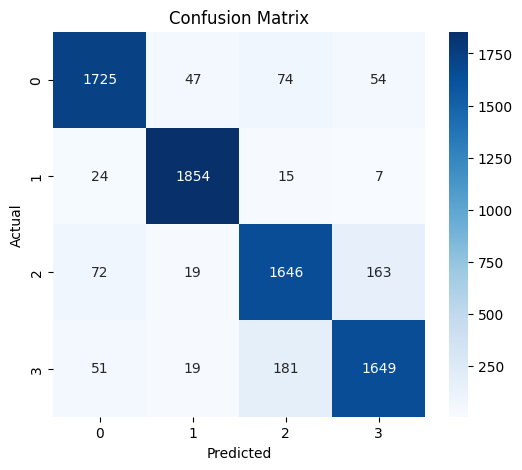

In [76]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('images/cm_mlp_embedding.png')
plt.show()

Per each sample ,the FLOPs carried can be calculated by the formula below. This is entirely dependent on the architecture.
$$FLOPs=2×(sequence length)×(kernel size)×(embedding dim)×(filters)$$

In [ ]:
def analytical_flops(model):
    flops = 0
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Dense):
            in_features = layer.input_shape[-1]
            out_features = layer.output_shape[-1]
            flops += 2 * in_features * out_features
    return flops

flops = analytical_flops(mlp_model)
print(f"Analytical FLOPs: {flops} FLOPs")


In [ ]:
results[('Matrix Embedding','MLP Model')] = {
                                    'Train':
                                            {'accuracy': train_accuracy,
                                            'f1_score': train_f1,
                                            'report': train_report,
                                            'training_time': cpu_time_train},
                                    'Test':
                                            {'accuracy': test_accuracy,
                                            'f1_score': test_f1,
                                            'report': test_report,
                                            'inference_time':cpu_time_inf,
                                            "flops/sample": flops}}

In [ ]:
# create DataFrame
import pandas as pd

# flatten nested dict into a list of rows
rows = []

for (vectorizer, model), metrics in results.items():
    row = {
        "Vectorizer": vectorizer,
        "Model": model,
        "Train_Accuracy": metrics["Train"]["accuracy"],
        "Train_F1": metrics["Train"]["f1_score"],
        "Test_Accuracy": metrics["Test"]["accuracy"],
        "Test_F1": metrics["Test"]["f1_score"],
        "Inference_Time": metrics["Test"].get("inference_time", None),
        "FLOPs_per_Sample": metrics["Test"].get("flops/sample", None),
        "Training_Time": metrics['Train'].get('training_time',None)
    }
    rows.append(row)

# create DataFrame
df_results = pd.DataFrame(rows)

# optional: set a clean display order
df_results = df_results[
    ["Vectorizer", "Model", "Train_Accuracy", "Train_F1",
     "Test_Accuracy", "Test_F1", "Inference_Time", "FLOPs_per_Sample","Training_Time"]
]

print(df_results)

In [ ]:
import pandas as pd
results = pd.read_csv('datasets/results.csv')

df = pd.concat([results, df_results], axis=0,ignore_index=True)

In [ ]:
df.reset_index().drop('index', axis=1)

In [ ]:
df.to_csv('datasets/results.csv')
df_results.to_csv('datasets/matrix_emb.csv')